# Day 1: API Data Extraction

In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fetch 60 days of live Bitcoin data at 2-minute intervals (40,000+ rows)
ticker = "BTC-USD"
print("Fetching real-time market data...")

# UPDATE: Changed period to "60d" and interval to "2m"
df = yf.download(tickers=ticker, period="60d", interval="2m")

print(f"Total rows fetched: {len(df)}")

Fetching real-time market data...


[*********************100%***********************]  1 of 1 completed

Total rows fetched: 24243


# Day 2: Data Cleaning & Formatting

In [3]:
# Reset index to convert 'Datetime' from an index into a standard column
df = df.reset_index()

# Flatten columns if yfinance creates a MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Fill any missing values forward to prevent gaps in our data
df = df.ffill()

# Convert all column names to lowercase for easier coding
df.columns = [col.lower() for col in df.columns]
print("Data cleaned and standardized.")

Data cleaned and standardized.


# Day 3: Moving Average Calculations

In [4]:
# Calculate 50-minute and 200-minute Simple Moving Averages (SMA)
df['sma_50'] = df['close'].rolling(window=50).mean()
df['sma_200'] = df['close'].rolling(window=200).mean()

# Calculate minute-by-minute percentage returns
df['returns'] = df['close'].pct_change()
print("Trend metrics calculated.")

Trend metrics calculated.


# Day 4: Statistical Volatility Spikes

In [5]:
# Calculate 30-minute rolling volatility (standard deviation)
df['volatility'] = df['returns'].rolling(window=30).std()

# Define the threshold for extreme volatility (top 5% highest spikes)
volatility_threshold = np.nanpercentile(df['volatility'].values, 95)

# Create a binary flag for high volatility events (1 = Yes, 0 = No)
df['high_volatility'] = np.where(df['volatility'] > volatility_threshold, 1, 0)

# Export the final processed dataset
df.to_csv("bitcoin_live_analysis.csv", index=False)
print("Anomalies detected and data exported to CSV.")

Anomalies detected and data exported to CSV.


# Day 5: Visualization Dashboard (Part 1 - Price Trends)

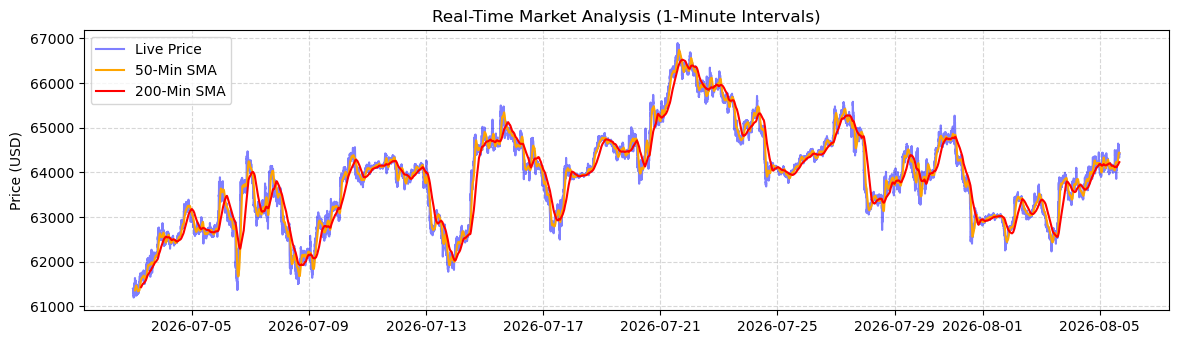

In [6]:
# Initialize a large visual dashboard
plt.figure(figsize=(14, 8))

# Top Chart: Price and Moving Averages
plt.subplot(2, 1, 1)
plt.plot(df['datetime'], df['close'], label='Live Price', color='blue', alpha=0.5)
plt.plot(df['datetime'], df['sma_50'], label='50-Min SMA', color='orange')
plt.plot(df['datetime'], df['sma_200'], label='200-Min SMA', color='red')
plt.title('Real-Time Market Analysis (1-Minute Intervals)')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# Day 6: Visualization Dashboard (Part 2 - Anomalies & Polish)

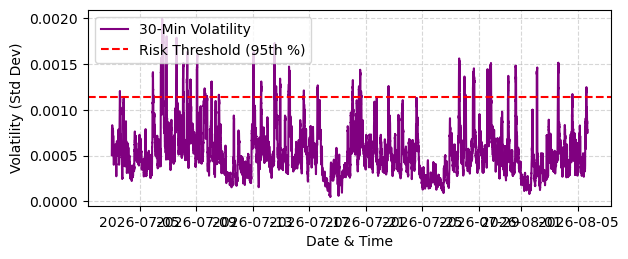

In [7]:
# Bottom Chart: Volatility and Anomaly Detection
plt.subplot(2, 1, 2)
plt.plot(df['datetime'], df['volatility'], label='30-Min Volatility', color='purple')
plt.axhline(y=volatility_threshold, color='red', linestyle='--', label='Risk Threshold (95th %)')
plt.xlabel('Date & Time')
plt.ylabel('Volatility (Std Dev)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# Display the final dashboard
plt.tight_layout()
plt.show()